# 🚲 Bike Demand Elasticity Modeling

**Author:** Praveen Kumar  
**Date:** 2026-03-22  

### 🎯 Objective
Build an end-to-end ML pipeline to:
- Predict bike demand
- Analyze feature importance
- Estimate demand elasticity

### 📊 Dataset
UCI Bike Sharing Dataset (hour.csv)

### 🔍 Pipeline Overview
1. Data Loading  
2. Cleaning  
3. Feature Engineering  
4. EDA  
5. Modeling  
6. Evaluation  
7. Elasticity Analysis  

## 1. 📦 Imports & Configuration

In [1]:
import os
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

## 2. 📂 Data Loading

In [2]:
BASE_PATH = "/Users/praveenkumar/Downloads/bike+sharing+dataset (1)"
df_raw = pd.read_csv(os.path.join(BASE_PATH, "hour.csv"))

df_raw.shape

(17379, 17)

## 3. 🔍 Basic Data Inspection

In [3]:
df_raw.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


In [5]:
df_raw.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


## 4. 🧹 Data Cleaning & Preprocessing

In [6]:
df = df_raw.copy()

df["dteday"] = pd.to_datetime(df["dteday"])

# Drop leakage
df.drop(columns=["instant", "casual", "registered"], inplace=True)

df.isnull().sum()

dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

## 5. ⚙️ Feature Engineering

In [7]:
df["year"] = df["dteday"].dt.year
df["month"] = df["dteday"].dt.month
df["day"] = df["dteday"].dt.day
df["day_of_week"] = df["dteday"].dt.dayofweek

# Cyclic features
df["hr_sin"] = np.sin(2 * np.pi * df["hr"] / 24)
df["hr_cos"] = np.cos(2 * np.pi * df["hr"] / 24)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Rush hour
df["is_rush_hour"] = df["hr"].apply(lambda h: 1 if h in range(7,10) or h in range(17,20) else 0)

# Interaction
df["temp_x_workday"] = df["temp"] * df["workingday"]

df.drop(columns=["dteday"], inplace=True)

df.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,...,year,month,day,day_of_week,hr_sin,hr_cos,month_sin,month_cos,is_rush_hour,temp_x_workday
0,1,0,1,0,0,6,0,1,0.24,0.2879,...,2011,1,1,5,0.000000,1.000000,0.5,0.866025,0,0.0
1,1,0,1,1,0,6,0,1,0.22,0.2727,...,2011,1,1,5,0.258819,0.965926,0.5,0.866025,0,0.0
2,1,0,1,2,0,6,0,1,0.22,0.2727,...,2011,1,1,5,0.500000,0.866025,0.5,0.866025,0,0.0
3,1,0,1,3,0,6,0,1,0.24,0.2879,...,2011,1,1,5,0.707107,0.707107,0.5,0.866025,0,0.0
4,1,0,1,4,0,6,0,1,0.24,0.2879,...,2011,1,1,5,0.866025,0.500000,0.5,0.866025,0,0.0


## 6. 📊 Target Variable Analysis

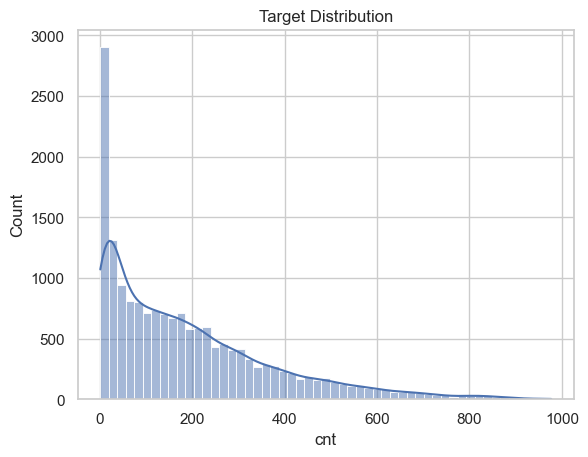

In [8]:
sns.histplot(df["cnt"], kde=True)
plt.title("Target Distribution")
plt.show()

## 7. ⏱ Time-Based Demand Analysis

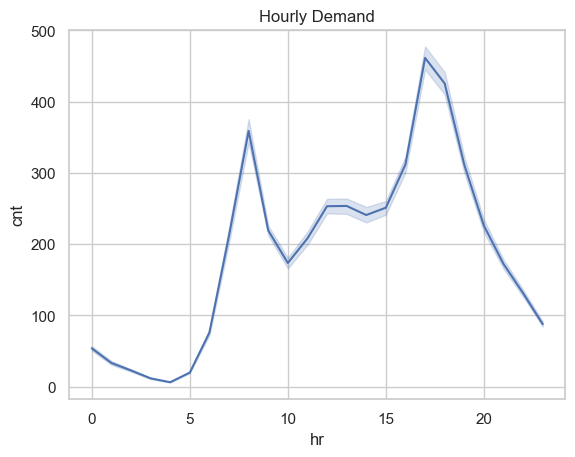

In [9]:
sns.lineplot(x="hr", y="cnt", data=df)
plt.title("Hourly Demand")
plt.show()

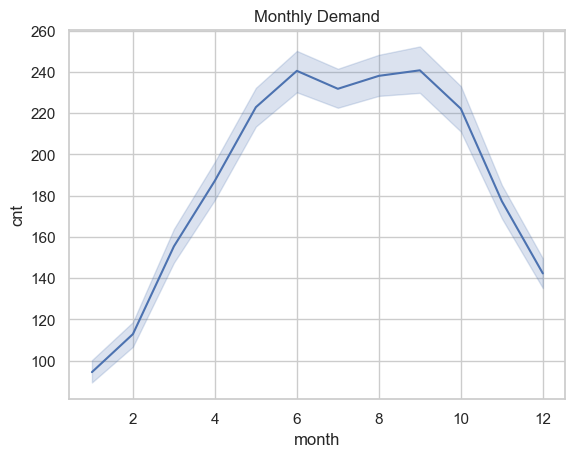

In [10]:
sns.lineplot(x="month", y="cnt", data=df)
plt.title("Monthly Demand")
plt.show()

## 8. 🔗 Feature vs Target Relationship

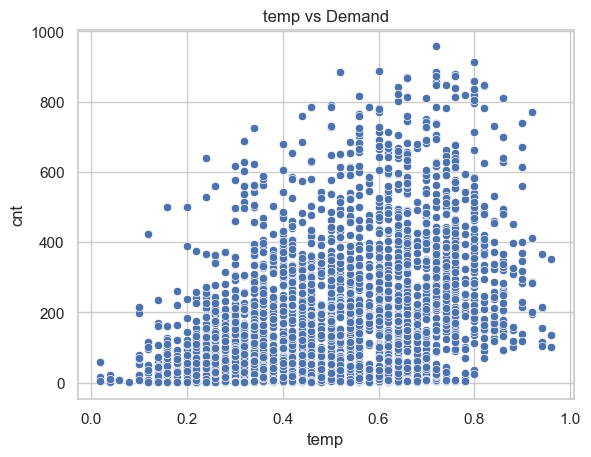

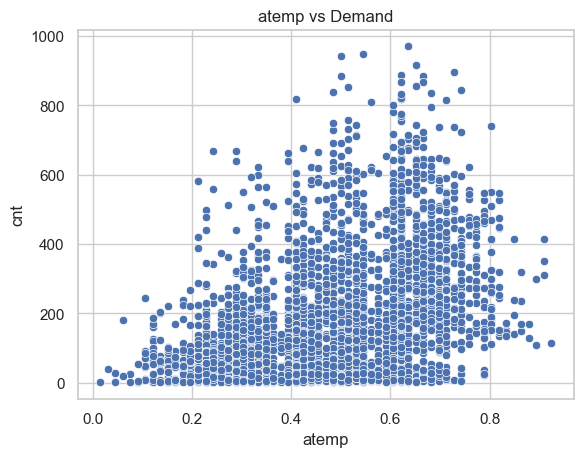

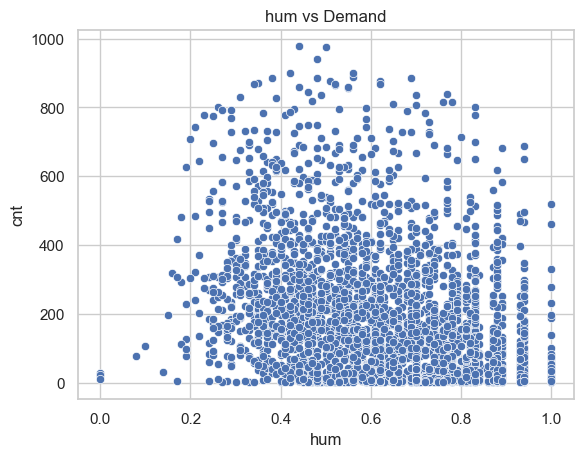

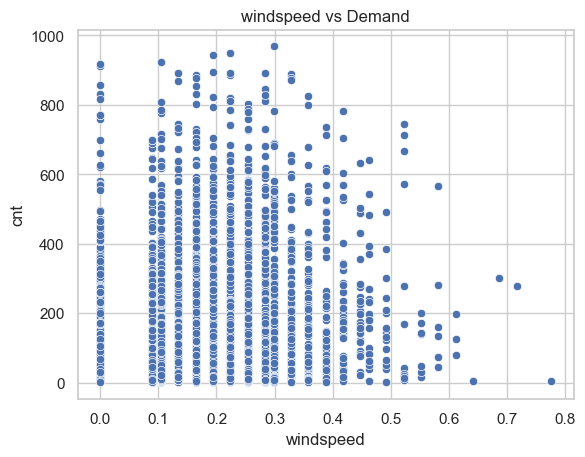

In [11]:
features = ["temp", "atemp", "hum", "windspeed"]

for col in features:
    sns.scatterplot(x=col, y="cnt", data=df.sample(3000))
    plt.title(f"{col} vs Demand")
    plt.show()

## 9. 🔥 Correlation & Multicollinearity Analysis

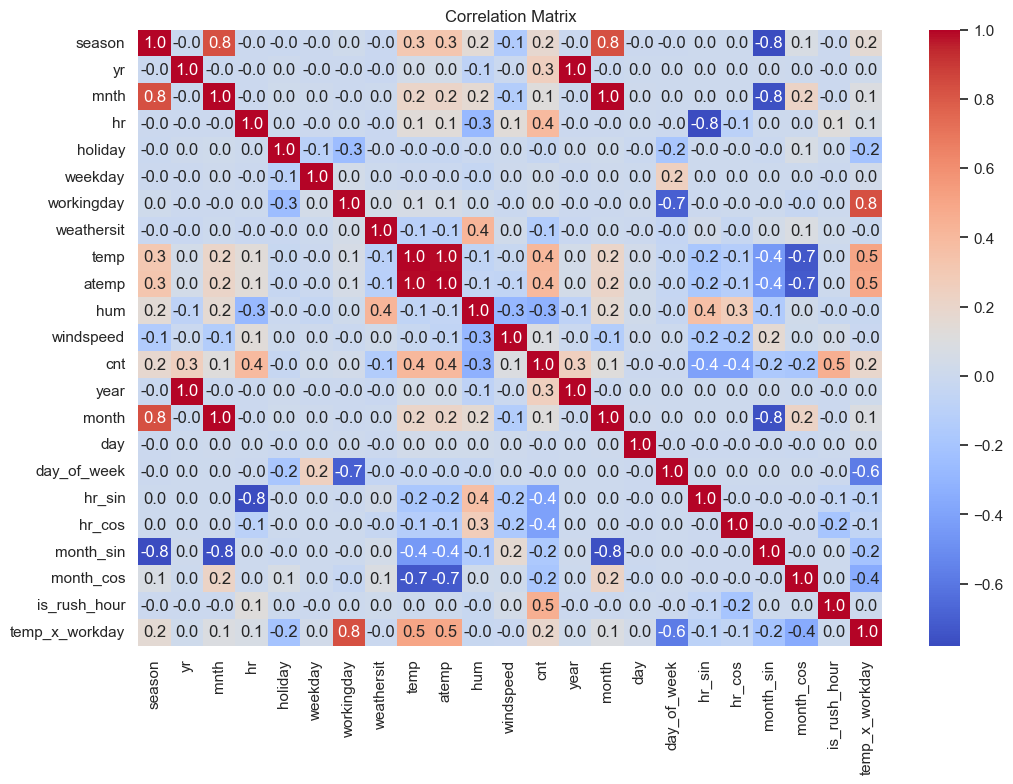

In [22]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm",annot=True,fmt=".1f")
plt.title("Correlation Matrix")
plt.show()

## 10. ✂️ Train-Test Split & Scaling

In [13]:
X = df.drop(columns=["cnt", "yr", "year"])
y = df["cnt"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

## 11. 🤖 Model Training

In [14]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "RF": RandomForestRegressor(n_estimators=150),
    "GB": GradientBoostingRegressor()
}

trained = {}

for name, model in models.items():
    if name in ["RF", "GB"]:
        model.fit(X_train, y_train)
    else:
        model.fit(X_train_sc, y_train)
        
    trained[name] = model

## 12. 📈 Model Evaluation

In [15]:
results = []

for name, model in trained.items():
    X_input = X_test if name in ["RF","GB"] else X_test_sc
    pred = model.predict(X_input)

    results.append({
        "Model": name,
        "R2": r2_score(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE": mean_absolute_error(y_test, pred)
    })

pd.DataFrame(results).sort_values("R2", ascending=False)

,Model,R2,RMSE,MAE
3,RF,0.878313,62.074667,40.229567
4,GB,0.826867,74.042841,51.250251
1,Ridge,0.588515,114.148281,82.373703
0,Linear,0.588509,114.149126,82.374126
2,Lasso,0.588056,114.212017,82.267774


## 13. 🌲 Feature Importance Analysis

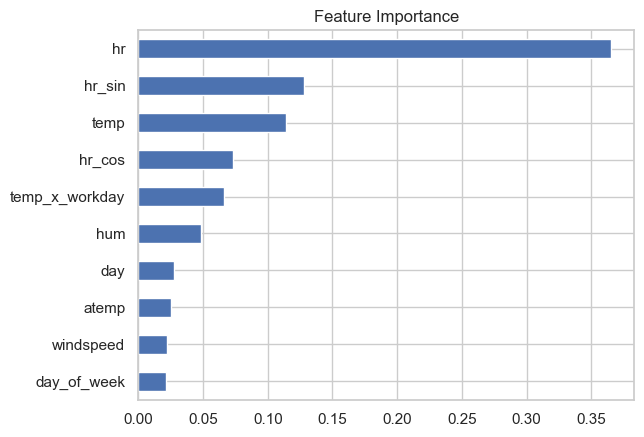

In [16]:
best_model = trained["RF"]

importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances.sort_values().tail(10).plot(kind="barh")
plt.title("Feature Importance")
plt.show()

## 14. 📉 Demand Elasticity Analysis

In [17]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

coef = lr.coef_
mean_X = X_train.mean()
mean_y = y_train.mean()

elasticity = coef * (mean_X / mean_y)

elasticity_df = pd.DataFrame({
    "Feature": X.columns,
    "Elasticity": elasticity
}).sort_values("Elasticity", key=abs, ascending=False)

elasticity_df.head(10)

,Feature,Elasticity
hr,hr,0.571979
season,season,0.358410
temp,temp,0.124950
weathersit,weathersit,-0.106800
workingday,workingday,0.098074
day,day,-0.097397
is_rush_hour,is_rush_hour,0.090737
weekday,weekday,0.080972
temp_x_workday,temp_x_workday,-0.061390
hum,hum,-0.060145


## 15. 📊 Residual Analysis

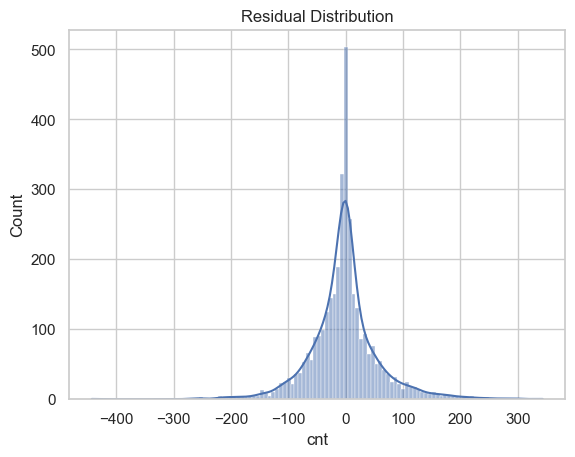

In [18]:
pred = best_model.predict(X_test)
residuals = y_test - pred

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

## 16. 💾 Model & Artifact Saving

In [19]:
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']